# Model wykrywania jazdy nieekonomicznej (non-eco)
Binary classifier: `non_eco` vs `normal`, trenowany na rzeczywistym zużyciu paliwa z licznika CAN (`fuel_cons` — narastający licznik w mL).

**Zasada:** model uczy się JAKIE zachowania kierowcy powodują wysokie zużycie. Zużycie paliwa jest używane tylko do etykietowania — NIE jako cecha wejściowa modelu.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, balanced_accuracy_score)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import emlearn

DATA_GLOB = "data/*.csv"
OUT_DIR   = "prepared_data"
os.makedirs(OUT_DIR, exist_ok=True)

WIN_SEC    = 5.0
STEP_SEC   = 2.5
TARGET_HZ  = 10.0
WIN_N      = int(WIN_SEC  * TARGET_HZ)   # 50 samples = exactly 5s
STEP_N     = int(STEP_SEC * TARGET_HZ)   # 25 samples = exactly 2.5s


## 1. Wczytanie i czyszczenie danych
Identyczna procedura jak w `ML_training.ipynb`: resample do stałej siatki 10Hz (100ms), ffill dla sygnałów CAN. Dodatkowo ffill dla `fuel_cons` — licznik narastający, trzyma ostatnią wartość do następnej ramki CAN.

In [2]:
def load_one_csv(path):
    df = pd.read_csv(path)

    needed = ["timestamp", "ignition", "speed", "rpm", "throttle", "brake", "rear_gear"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if "fuel_cons" in df.columns:
        df["fuel_cons"] = pd.to_numeric(df["fuel_cons"], errors="coerce")

    df = df.dropna(subset=needed).copy()
    df = df.sort_values("timestamp")
    df = df.drop_duplicates(subset=["timestamp"], keep="first")

    # Resample to fixed 10Hz grid before filtering
    t_start = int(df["timestamp"].iloc[0] // 100) * 100
    t_end   = int(df["timestamp"].iloc[-1] // 100) * 100
    grid = np.arange(t_start, t_end + 100, 100, dtype=np.int64)

    df = df.set_index("timestamp")
    df = df.reindex(df.index.union(grid)).sort_index()

    for col in ["speed", "rpm", "throttle", "brake", "ignition", "rear_gear"]:
        df[col] = df[col].ffill().fillna(0)
    if "fuel_cons" in df.columns:
        df["fuel_cons"] = df["fuel_cons"].ffill()  # holds last value like odometer

    df = df.reindex(grid).reset_index().rename(columns={"index": "timestamp"})

    df = df[(df["ignition"] == 1) & (df["rear_gear"] == 0) & (df["speed"] >= 0)].copy()
    if df.empty:
        return df

    df = df.reset_index(drop=True)
    DT = 0.1
    boundary = (df["timestamp"].diff() > 150).fillna(True)

    df["dt"] = DT
    df["a_ms2"] = (df["speed"].diff() / 3.6) / DT
    df["a_ms2"] = df["a_ms2"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "a_ms2"] = 0.0

    df["jerk_ms3"] = df["a_ms2"].diff() / DT
    df["jerk_ms3"] = df["jerk_ms3"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "jerk_ms3"] = 0.0

    df["d_throttle_s"] = df["throttle"].diff() / DT
    df["d_throttle_s"] = df["d_throttle_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_throttle_s"] = 0.0

    df["d_brake_s"] = df["brake"].diff() / DT
    df["d_brake_s"] = df["d_brake_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_brake_s"] = 0.0

    df["source_file"] = os.path.basename(path)
    return df.reset_index(drop=True)

files   = sorted(glob.glob(DATA_GLOB))
trips   = [load_one_csv(p) for p in files]
raw_all = pd.concat(trips, ignore_index=True)

print("Liczba plikow:", len(files))
print("Liczba wierszy po czyszczeniu:", len(raw_all))
has_fc = raw_all["fuel_cons"].notna().mean()
print(f"fuel_cons dostepnosc: {has_fc:.1%}")


Liczba plikow: 29
Liczba wierszy po czyszczeniu: 567382
fuel_cons dostepnosc: 100.0%


## 2. Okna czasowe + zużycie paliwa
Dla każdego okna liczymy `l_per_100km` ze wzoru:

```
fuel_diff [mL] = fuel_cons[-1] - fuel_cons[0]
dist_km        = sum(speed_kmh) / 3.6 * 0.1 / 1000
l_per_100km    = fuel_diff / (10 * dist_km)
```

`l_per_100km` NIE jest cechą wejściową modelu — służy tylko do nadania etykiety.

In [3]:
def make_window_features(df, win_n=WIN_N, step_n=STEP_N):
    rows = []
    if len(df) < win_n:
        return pd.DataFrame()

    has_fuel = "fuel_cons" in df.columns

    for start in range(0, len(df) - win_n + 1, step_n):
        w = df.iloc[start:start + win_n]

        if w["speed"].mean() < 2.0:
            continue

        feat = {
            "source_file":   w["source_file"].iloc[-1],
            "ts_end":        int(w["timestamp"].iloc[-1]),

            "speed_mean":    w["speed"].mean(),
            "speed_std":     w["speed"].std(ddof=0),
            "speed_p95":     np.percentile(w["speed"], 95),

            "rpm_mean":      w["rpm"].mean(),
            "rpm_std":       w["rpm"].std(ddof=0),
            "rpm_p95":       np.percentile(w["rpm"], 95),

            "throttle_mean": w["throttle"].mean(),
            "throttle_std":  w["throttle"].std(ddof=0),
            "throttle_p95":  np.percentile(w["throttle"], 95),
            "throttle_dp95": np.percentile(w["d_throttle_s"], 95),

            "brake_mean":    w["brake"].mean(),
            "brake_p95":     np.percentile(w["brake"], 95),
            "brake_dp95":    np.percentile(w["d_brake_s"], 95),

            "a_mean":        w["a_ms2"].mean(),
            "a_std":         w["a_ms2"].std(ddof=0),
            "a_p95":         np.percentile(w["a_ms2"], 95),
            "a_p05":         np.percentile(w["a_ms2"], 5),
            "abs_a_mean":    np.abs(w["a_ms2"]).mean(),

            "jerk_abs_mean": np.abs(w["jerk_ms3"]).mean(),
            "jerk_abs_p95":  np.percentile(np.abs(w["jerk_ms3"]), 95),
        }

        # Fuel consumption — label source only, not a model feature
        if has_fuel:
            fc = w["fuel_cons"].dropna()
            if len(fc) >= 2:
                fuel_diff = fc.iloc[-1] - fc.iloc[0]
                dist_km   = w["speed"].sum() / 3.6 * 0.1 / 1000
                if dist_km > 0.05 and fuel_diff >= 0:
                    feat["l_per_100km"] = fuel_diff / (10.0 * dist_km)
                else:
                    feat["l_per_100km"] = np.nan
            else:
                feat["l_per_100km"] = np.nan
        else:
            feat["l_per_100km"] = np.nan

        rows.append(feat)

    return pd.DataFrame(rows)

windows = []
for t in trips:
    wf = make_window_features(t)
    if len(wf):
        windows.append(wf)

feat_df = pd.concat(windows, ignore_index=True)
print("Liczba okien:", len(feat_df))
print(f"Okna z l_per_100km: {feat_df['l_per_100km'].notna().sum()} "
      f"({feat_df['l_per_100km'].notna().mean():.1%})")
feat_df.head()


Liczba okien: 20954
Okna z l_per_100km: 17104 (81.6%)


,source_file,ts_end,speed_mean,speed_std,speed_p95,rpm_mean,rpm_std,rpm_p95,throttle_mean,throttle_std,...,brake_p95,brake_dp95,a_mean,a_std,a_p95,a_p05,abs_a_mean,jerk_abs_mean,jerk_abs_p95,l_per_100km
0,20260404_091932.csv,137800,2.00,3.200000,8.00,1215.90,264.593216,1368.55,1.66,6.192286,...,0.0,0.0,0.444444,1.401058,2.777778,0.000000,0.444444,5.555556,27.777778,NaN
1,20260404_091932.csv,140300,6.94,3.971952,12.00,1304.04,159.428349,1594.00,22.74,25.543539,...,0.0,0.0,0.666667,1.625415,2.777778,0.000000,0.777778,12.222222,43.055556,NaN
2,20260404_091932.csv,142800,11.82,2.355334,15.55,1281.12,191.020380,1594.00,40.60,20.632014,...,0.0,0.0,0.444444,1.160034,2.777778,0.000000,0.555556,11.111111,27.777778,NaN
3,20260404_091932.csv,145300,15.06,1.678213,17.00,1200.60,105.997358,1310.10,25.00,23.583045,...,0.0,0.0,0.166667,1.166667,2.777778,-1.527778,0.500000,10.000000,27.777778,NaN
4,20260404_091932.csv,147800,15.08,1.481081,17.00,1168.34,97.832430,1307.65,5.48,14.337699,...,13.1,42.0,-0.166667,1.025899,0.000000,-2.777778,0.388889,7.777778,27.777778,NaN


## 3. Eksploracja zużycia paliwa
Sprawdzamy rozkład `l_per_100km` w podziale na zakresy prędkości. Zużycie jest kontekstowe — przy niskiej prędkości naturalnie wyższe.

Okna do analizy: 17102

=== Globalne percentyle l_per_100km ===
p5      1.13
p10     2.20
p25     4.70
p50     7.15
p75     9.54
p90    11.66
p95    13.51

=== Percentyle l_per_100km wg zakresu prędkości ===
                   count  mean   std  min   25%   50%    75%    90%    max
speed_bin                                                                 
miasto (<50)      1527.0  7.32  6.37  0.0  2.92  5.86  10.33  16.03  39.65
trasa (50-90)     5643.0  5.78  3.87  0.0  3.32  5.40   7.52  10.24  32.66
autostrada (>90)  9932.0  8.10  3.28  0.0  6.19  8.16  10.04  11.73  30.06


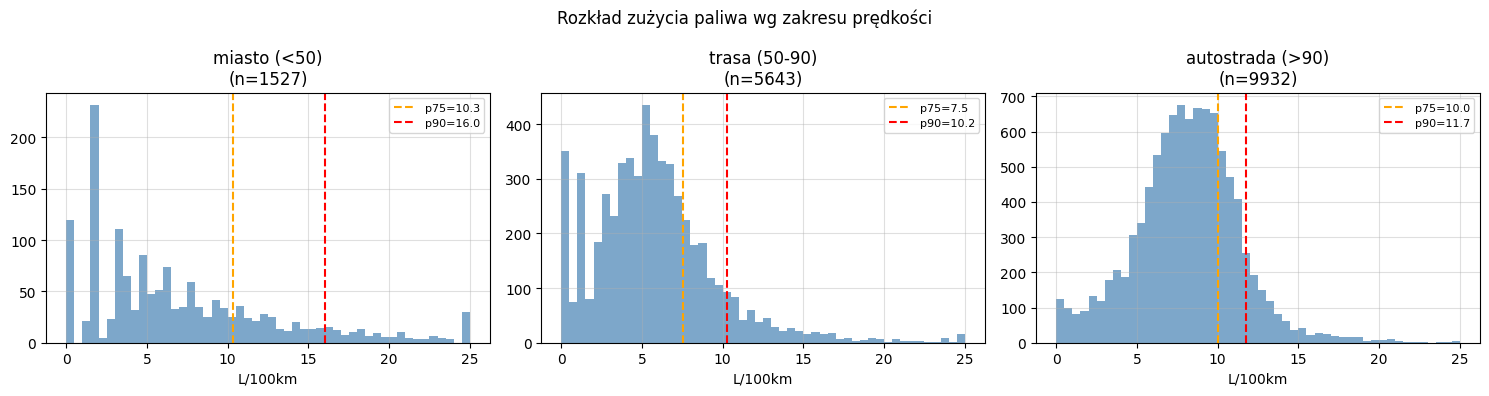

In [4]:
fc_df = feat_df.dropna(subset=["l_per_100km"]).copy()
fc_df = fc_df[fc_df["speed_mean"] >= 10]        # pomijamy prawie-stój
fc_df = fc_df[fc_df["l_per_100km"] <= 40]       # odrzucamy nierealne wartości (rozruch, korek)

print(f"Okna do analizy: {len(fc_df)}")

# Percentyle globalne
percs = [5, 10, 25, 50, 75, 90, 95]
print("\n=== Globalne percentyle l_per_100km ===")
print(pd.Series(np.percentile(fc_df["l_per_100km"], percs),
                index=[f"p{p}" for p in percs]).round(2).to_string())

# Percentyle w zakresach prędkości
bins   = [0,  50,  90, 200]
labels = ["miasto (<50)", "trasa (50-90)", "autostrada (>90)"]
fc_df["speed_bin"] = pd.cut(fc_df["speed_mean"], bins=bins, labels=labels)

print("\n=== Percentyle l_per_100km wg zakresu prędkości ===")
print(fc_df.groupby("speed_bin", observed=True)["l_per_100km"]
      .describe(percentiles=[.25, .5, .75, .9])
      .round(2).to_string())

# Histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, grp) in zip(axes,
        fc_df.groupby("speed_bin", observed=True)):
    vals = grp["l_per_100km"].clip(0, 25)
    ax.hist(vals, bins=50, color="steelblue", alpha=0.7)
    for p, col in [(75, "orange"), (90, "red")]:
        v = np.percentile(grp["l_per_100km"], p)
        ax.axvline(v, color=col, linestyle="--", label=f"p{p}={v:.1f}")
    ax.set_title(f"{label}\n(n={len(grp)})")
    ax.set_xlabel("L/100km")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle("Rozkład zużycia paliwa wg zakresu prędkości", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Etykiety non_eco
Okno jest `non_eco` jeśli zużycie paliwa przekracza **p75 dla danego zakresu prędkości**. Porównujemy do mediany w kontekście — nie globalnie, bo przy niskiej prędkości wysokie zużycie jest normalne.

Okna bez wiarygodnego `l_per_100km` (zbyt wolna jazda, brak sygnału) → pomijane.

In [5]:
# Compute per-speed-bin p75 thresholds
bins   = [0,  50,  90, 200]
labels_bin = ["miasto", "trasa", "autostrada"]

fc_clean = feat_df.dropna(subset=["l_per_100km"]).copy()
fc_clean = fc_clean[fc_clean["speed_mean"] >= 10]
fc_clean = fc_clean[fc_clean["l_per_100km"] <= 40]
fc_clean["speed_bin"] = pd.cut(fc_clean["speed_mean"], bins=bins, labels=labels_bin)

thresholds = (fc_clean.groupby("speed_bin", observed=True)["l_per_100km"]
              .quantile(0.75).to_dict())
print("Progi non_eco (p75 l_per_100km wg prędkości):")
for k, v in thresholds.items():
    print(f"  {k}: > {v:.2f} L/100km")

def label_noneco(row, thresh=thresholds):
    if pd.isna(row["l_per_100km"]) or row["speed_mean"] < 10 or row["l_per_100km"] > 40:
        return None  # drop
    if row["speed_mean"] < 50:
        t = thresh.get("miasto", 99)
    elif row["speed_mean"] < 90:
        t = thresh.get("trasa", 99)
    else:
        t = thresh.get("autostrada", 99)
    return "non_eco" if row["l_per_100km"] > t else "normal"

feat_df["label"] = feat_df.apply(label_noneco, axis=1)

labeled = feat_df.dropna(subset=["label"]).copy()
print("\n=== Rozkład etykiet ===")
print(labeled["label"].value_counts())
print(f"Odrzucono okien (brak paliwa / zbyt wolno): {feat_df['label'].isna().sum()}")

feature_cols = [c for c in labeled.columns
                if c not in ["source_file", "ts_end", "label", "l_per_100km"]]
X      = labeled[feature_cols].copy()
y      = labeled["label"].copy()
groups = labeled["source_file"].copy()

split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

quantizer = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
X_train_q = np.rint(quantizer.fit_transform(X_train)).astype(np.int16)
X_test_q  = np.rint(quantizer.transform(X_test)).astype(np.int16)

print(f"\nTrain: {len(X_train)}  Test: {len(X_test)}")


Progi non_eco (p75 l_per_100km wg prędkości):
  miasto: > 10.33 L/100km
  trasa: > 7.52 L/100km
  autostrada: > 10.04 L/100km

=== Rozkład etykiet ===
label
normal     12826
non_eco     4276
Name: count, dtype: int64
Odrzucono okien (brak paliwa / zbyt wolno): 3852

Train: 9579  Test: 7523


## 5. Trening: ExtraTrees vs RandomForest
Porównujemy oba modele na tym samym podziale.

In [6]:
COMMON = dict(
    n_estimators=60,
    max_depth=7,
    min_samples_leaf=12,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

models = {
    "ExtraTrees":   ExtraTreesClassifier(**COMMON),
    "RandomForest": RandomForestClassifier(**COMMON),
}

for name, m in models.items():
    m.fit(X_train_q, y_train)
    y_pred = m.predict(X_test_q)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1          : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred, digits=4))



  ExtraTrees
Balanced accuracy : 0.6932
Macro F1          : 0.7091
              precision    recall  f1-score   support

     non_eco     0.7576    0.4569    0.5700      2449
      normal     0.7800    0.9294    0.8482      5074

    accuracy                         0.7756      7523
   macro avg     0.7688    0.6932    0.7091      7523
weighted avg     0.7727    0.7756    0.7577      7523


  RandomForest
Balanced accuracy : 0.6959
Macro F1          : 0.7153
              precision    recall  f1-score   support

     non_eco     0.8630    0.4243    0.5688      2449
      normal     0.7769    0.9675    0.8618      5074

    accuracy                         0.7906      7523
   macro avg     0.8199    0.6959    0.7153      7523
weighted avg     0.8049    0.7906    0.7664      7523



## 6. Cross-walidacja (GroupKFold, 5 foldów)
Każdy fold = inne pliki — test generalizacji na nieznanych trasach.

In [7]:
gkf = GroupKFold(n_splits=5)

for name, ModelClass in [("ExtraTrees", ExtraTreesClassifier),
                          ("RandomForest", RandomForestClassifier)]:
    cv_f1, cv_ba = [], []
    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        sc = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
        Xtr = np.rint(sc.fit_transform(X.iloc[tr_idx])).astype(np.int16)
        Xva = np.rint(sc.transform(X.iloc[va_idx])).astype(np.int16)
        m   = ModelClass(**COMMON)
        m.fit(Xtr, y.iloc[tr_idx])
        yp  = m.predict(Xva)
        cv_f1.append(f1_score(y.iloc[va_idx], yp, average="macro"))
        cv_ba.append(balanced_accuracy_score(y.iloc[va_idx], yp))

    print(f"{name}:")
    print(f"  Macro F1     : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")
    print(f"  Balanced acc : {np.mean(cv_ba):.4f} ± {np.std(cv_ba):.4f}\n")


ExtraTrees:
  Macro F1     : 0.7701 ± 0.0937
  Balanced acc : 0.8310 ± 0.0702

RandomForest:
  Macro F1     : 0.8389 ± 0.0806
  Balanced acc : 0.8797 ± 0.0238



## 7. Eksport najlepszego modelu
Eksportujemy lepszy z dwóch modeli do `prepared_data/noneco_model.h`.

In [8]:
# Wybierz model z lepszym CV F1 (uruchom po sekcji 6)
best_model = models["ExtraTrees"]   # zmień jeśli RF okazał się lepszy

cmodel = emlearn.convert(best_model, method="inline", dtype="int16_t", leaf_bits=6)
cmodel.save(file=os.path.join(OUT_DIR, "noneco_model.h"), name="noneco_model")

q_meta = {
    "feature_order": feature_cols,
    "scale": quantizer.scale_.tolist(),
    "min":   quantizer.min_.tolist(),
    "class_order": ["non_eco", "normal"]
}
with open(os.path.join(OUT_DIR, "noneco_quantizer.json"), "w", encoding="utf-8") as f:
    json.dump(q_meta, f, indent=2)

print("Zapisano noneco_model.h i noneco_quantizer.json")


Zapisano noneco_model.h i noneco_quantizer.json
